In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys, pickle
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm
#from matplotlib import rc
# rc('text', usetex=True)
# # Set the font family to 'serif' and specify a LaTeX font like 'Computer Modern'
# rc('font', family='serif', serif=['Computer Modern'])

import agama 
agama.setUnits(mass=1, length=1, velocity=1) #Msol, kpc, km/s. Time is in kpc/(kms/s)
# agama.setNumThreads(48)  

# sys.path.insert(1, '/mnt/d/Research/')
# import compute_characteristics_ut as cc

import jet_sim_funcs as jsf

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

from jet_likelihood import log_likelihood, make_spline, log_prior, log_probability
from jet_sim_funcs import create_stream_particle_spray, generate_stream_coords

In [2]:
# Define file paths
BASE_POT_PATH = 'Nbody_streams/nbody_streams/data/potentials'
potMW_path = os.path.join(BASE_POT_PATH, 'MWPotential22.ini')
## potential models to load
potMW = agama.Potential(file=potMW_path)
potTotal= agama.Potential(potMW)

In [3]:
#Reading in all our data
member_path = 'jet_members.csv'

jet_table = pd.read_csv(member_path)

def select_median_array(data_file):
    
    '''
    Function takes in data table and spits out median star and data_dict
    '''
    
    df = data_file

    select_phi1 = (df['phi1'] > -1.0) & (df['phi1'] < 5.0)
    
    select_distance = (df['bhb_dist'].notna())
    dist_phi1 = df.loc[select_distance, 'phi1']
    dist = df.loc[select_distance, 'bhb_dist']


    coefficients = np.polyfit(dist_phi1, dist, deg=1)

    distance_fit = np.poly1d(coefficients)

    phi1med = np.median(df.loc[select_phi1,'phi1'])
    phi2med = np.median(df.loc[select_phi1,'phi2'])
    distmed = np.median(df.loc[select_phi1 & select_distance, 'bhb_dist'])
    ramed = np.median(df.loc[select_phi1,'ra'])
    decmed = np.median(df.loc[select_phi1,'dec'])
    pmramed = np.median(df.loc[select_phi1, 'pmra'])
    pmdecmed = np.median(df.loc[select_phi1, 'pmdec'])
    rvmed = np.median(df.loc[select_phi1, 'vel_calib'])

    prog_pars = [float(ramed), float(decmed), float(distmed), float(pmramed), float(pmdecmed), float(rvmed)]

    return df, distance_fit, prog_pars

df, distance_fit, prog_pars = select_median_array(jet_table)

data_dict = dict(
    phi1_obs = df['phi1'].values,
    phi2_obs = df['phi2'].values,
    rv_obs = df['vel_calib'].values,
    rv_obs_errors = df['vel_calib_std'].values,
    dist_obs = df['bhb_dist'].values,
    dist_obs_errors = ((df['bhb_dist'].values)*0.1),
    pmra_cosdec_obs = df['pmra'].values,
    pmra_cosdec_obs_errors = df['pmra_error'].values,
    pmdec_obs = df['pmdec'].values,
    pmdec_obs_errors = df['pmdec_error'].values,
)
print(prog_pars)

[140.4535, -19.511558333333333, 29.880800350338735, -0.7610245282040371, -1.5673852411786384, 274.0931282785484]


In [4]:
#coordinate transform (useful for plotting)
def icrs_to_jet(ra_deg, dec_deg):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> Jet phi1, phi2
    Using the rotation matrix from Shipp+2019
    ra_deg: icrs deg [degrees]
    dec_deg: icrs deg [degrees]
    """
    ra_rad = np.radians(ra_deg)
    dec_rad = np.radians(dec_deg)
    
    R = np.array(
        [
            [-0.69796993, 0.6112632, -0.37308885],
            [-0.62616799, -0.26812463, 0.7321358],
            [0.34749337, 0.74462505, 0.56989637],
        ]
    )

    icrs_vec = np.vstack(
        [
            np.cos(ra_rad) * np.cos(dec_rad),
            np.sin(ra_rad) * np.cos(dec_rad),
            np.sin(dec_rad),
        ]
    ).T

    stream_frame_vec = np.einsum("ij,kj->ki", R, icrs_vec)

    phi1 = np.arctan2(stream_frame_vec[:, 1], stream_frame_vec[:, 0]) * 180 / np.pi
    phi2 = np.arcsin(stream_frame_vec[:, 2]) * 180 / np.pi

    return phi1, phi2

In [5]:
%%time
prog_coords_today = [140.4535, -19.511558333333333, 29.880800350338735, -0.7610245282040371, -1.5673852411786384, 274.0931282785484]

ra, dec, dist, pmra, pmdec, rv = prog_coords_today

jet_c = coord.SkyCoord(
    ra=ra*u.degree, dec=dec*u.degree, distance=dist*u.kpc, 
    pm_ra_cosdec=pmra*u.mas/u.yr,
    pm_dec=pmdec*u.mas/u.yr,
    radial_velocity=rv*u.km/u.s
)

rep = jet_c.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_wtoday = np.array(
    [rep.x.value, rep.y.value, rep.z.value,
     rep.v_x.value, rep.v_y.value, rep.v_z.value]
) # units here are kpc, km/s


# # stream progenitor profile parameters
prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc
Age_stream_inGyr = 6.0 # Gyr --<

# # num_particles for the spray model: 
num_particles = 1_000 # # preferably a multiple of 2, leading+trailing arm

# Test out a particle-spray simulation
stream_unperturb = jsf.create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    # add_perturber={'mass':0},
)

CPU times: user 11.3 s, sys: 341 ms, total: 11.7 s
Wall time: 107 ms


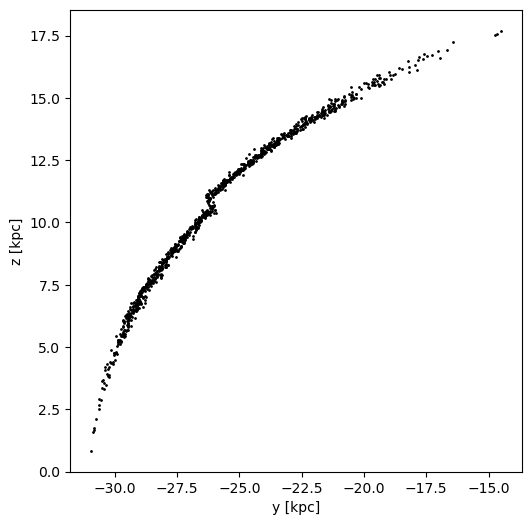

In [6]:
fig, ax = plt.subplots(1, 1, dpi=100)
fig.set_size_inches(6, 6)
ax.scatter(stream_unperturb['part_xv'][:, 1], stream_unperturb['part_xv'][:, 2], s=1, rasterized=True, color='k')
ax.set_xlabel('y [kpc]')
ax.set_ylabel('z [kpc]')
# ax.set_xlim(-10,10)
# ax.set_ylim(17,21)
ax.set_aspect('equal')

In [8]:
#MCMC fit
nwalkers = 200
niter = 1800

#Taking a fraction of the prior range 
initial = prog_pars
ndim = len(initial)
p0 = [np.array(initial) + 1e-3 * np.random.randn(ndim) for i in range(nwalkers)]

data = (data_dict, potTotal)

def main(p0,nwalkers,niter,ndim,log_probability,data, nburnin=200):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=data)
    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, nburnin, progress = True)
    print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}") #tells us how much of the burn-ins were accepted; 0.2-0.5 good
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter, progress = True)

    return sampler, pos, prob, state

In [9]:
sampler, pos, prob, state = main(p0,nwalkers,niter,ndim,log_probability, data)

Running burn-in...


100%|██████████| 200/200 [53:38<00:00, 16.09s/it]


Mean acceptance fraction: 0.191
Running production...


100%|██████████| 1800/1800 [7:55:30<00:00, 15.85s/it]  


In [10]:
#pulling out the values generated by the MCMC sampler XD
samples = sampler.flatchain
prog_pars_max  = samples[np.argmax(sampler.flatlnprobability)]
print(prog_pars_max)

ra_best, dec_best, dist_best, pmra_best, pmdec_best, rv_best = prog_pars_max

jet_c_best = coord.SkyCoord(
    ra=ra_best*u.degree, dec=dec_best*u.degree, distance=dist_best*u.kpc, 
    pm_ra_cosdec=pmra_best*u.mas/u.yr,
    pm_dec=pmdec_best*u.mas/u.yr,
    radial_velocity=rv_best*u.km/u.s
)

rep_best = jet_c_best.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_best_gal = np.array(
    [rep_best.x.value, rep_best.y.value, rep_best.z.value,
     rep_best.v_x.value, rep_best.v_y.value, rep_best.v_z.value]
) # units here are kpc, km/s

[140.36080157 -19.69651503  30.13111577  -0.70276513  -1.55177319
 274.6929843 ]


In [11]:
# # stream progenitor profile parameters
prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc
Age_stream_inGyr = 6.0 # Gyr --<

# # num_particles for the spray model: 
num_particles = 2_000 # # preferably a multiple of 2, leading+trailing arm

#generate the stream with best_fit_params
gen_best_stream = jsf.create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_best_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

best_stream_model = gen_best_stream['part_xv']

galcen_best_stream = coord.Galactocentric(
        x=best_stream_model[:,0] * u.kpc,
        y=best_stream_model[:,1] * u.kpc,
        z=best_stream_model[:,2] * u.kpc,
        v_x=best_stream_model[:,3] * u.km/u.s,
        v_y=best_stream_model[:,4] * u.km/u.s,
        v_z=best_stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_best_stream = galcen_best_stream.transform_to(coord.ICRS())

ra_max = icrs_best_stream.ra.value
dec_max = icrs_best_stream.dec.value
dist_max = icrs_best_stream.distance.value
pmra_max = icrs_best_stream.pm_ra_cosdec.value
pmdec_max = icrs_best_stream.pm_dec.value
rv_max = icrs_best_stream.radial_velocity.value

phi1_max, phi2_max = icrs_to_jet(ra_max, dec_max)

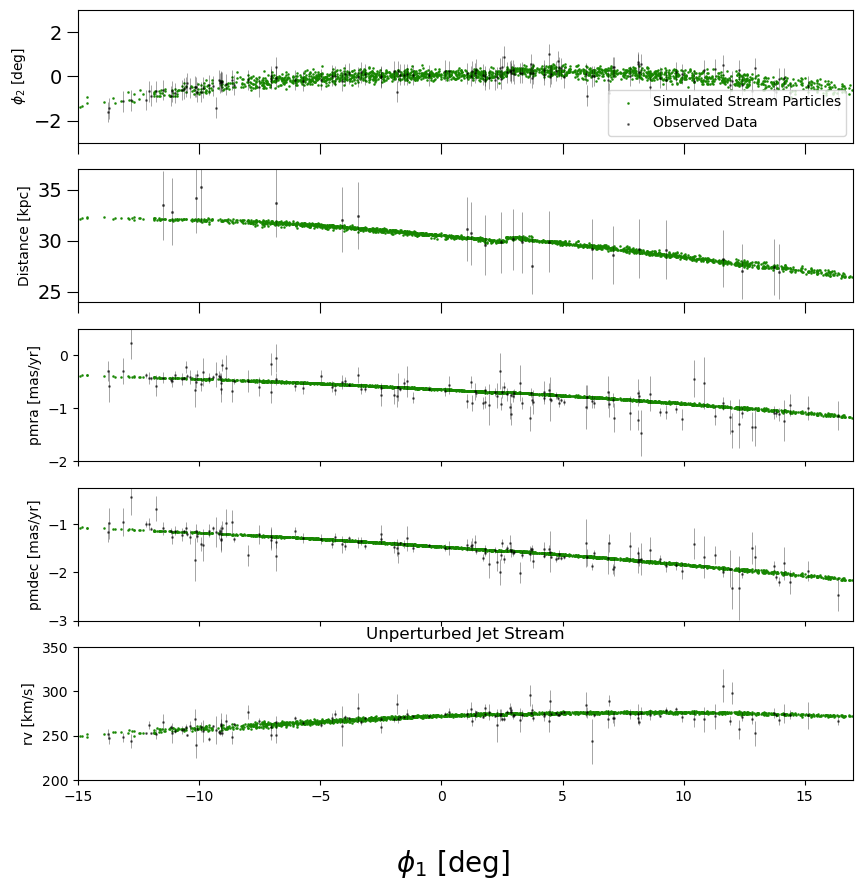

In [18]:
#plot with best-fit progenitor IC's from MCMC!

fig, ax = plt.subplots(5,1, sharex = True)
fig.set_size_inches(10,10)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-15,17)
ax[-1].set_title(label ='Unperturbed Jet Stream',loc='center' )
#simulation
ax[0].scatter(phi1_max, phi2_max,s=0.75,color='#168600', alpha= 0.9, label = 'Simulated Stream Particles')
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-3,3)
ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)

ax[1].scatter(phi1_max, dist_max,s=0.75,color='#168600',alpha= 0.9 )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
ax[1].set_ylim(24,37)

ax[2].scatter(phi1_max, pmra_max,s=0.75,color='#168600',alpha= 0.9 )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
ax[2].set_ylim(-2,0.5)

ax[3].scatter(phi1_max, pmdec_max,s=0.75,color='#168600',alpha= 0.9 )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[3].set_ylim(-3,-0.25)

ax[4].scatter(phi1_max, rv_max,s=0.75,color='#168600',alpha= 0.9)
ax[4].set_ylabel('rv [km/s]', fontsize=10)
ax[4].set_ylim(200,350)

#data
ax[0].scatter(df['phi1'], df['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
ax[0].errorbar(df['phi1'], df['phi2'], yerr=np.nanstd(df['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df['phi1'], df['bhb_dist'],s=1.5,color='k', alpha = 0.5)
ax[1].errorbar(df['phi1'],df['bhb_dist'], yerr=((df['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df['phi1'], df['pmra'],s=1,color='k', alpha = 0.5)
ax[2].errorbar(df['phi1'], df['pmra'], yerr=df['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df['phi1'], df['pmdec'],s=1,color='k',alpha = 0.5)
ax[3].errorbar(df['phi1'], df['pmdec'], yerr=df['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df['phi1'], df['vel_calib'],s=1,color='k', alpha = 0.5)
ax[4].errorbar(df['phi1'], df['vel_calib'], yerr=df['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[0].legend(loc = 'lower right')
fig.savefig('jet_mcmc_1.pdf')

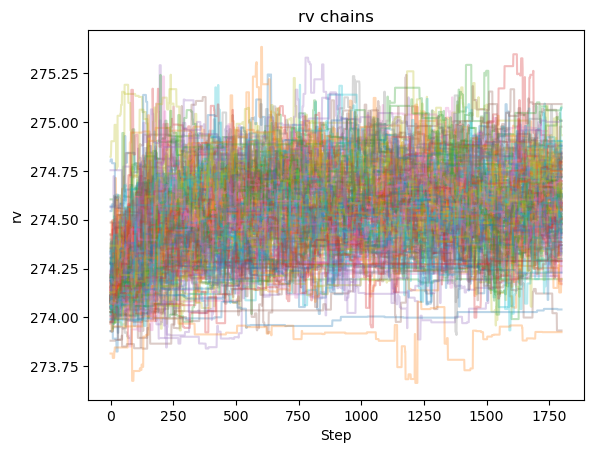

In [19]:
chain = sampler.get_chain()  
# shape: (n_steps, n_walkers, n_dim)
param_index = 5  # which parameter
plt.figure()
plt.plot(chain[:, :, param_index], alpha=0.3)
plt.xlabel("Step")
plt.ylabel("rv")
plt.title("rv chains")
plt.show()

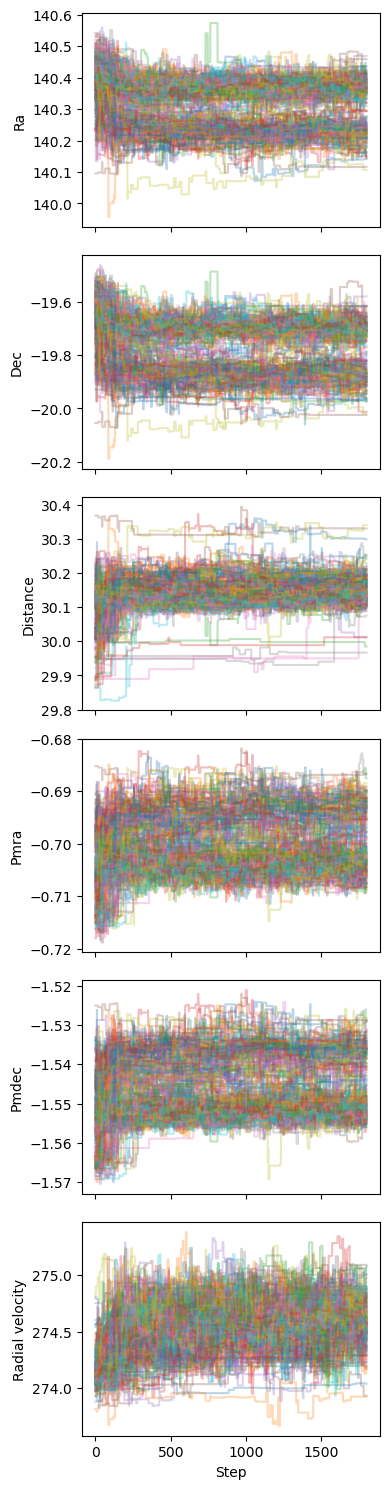

<Figure size 640x480 with 0 Axes>

In [20]:
n_steps, n_walkers, n_dim = chain.shape

fig, axes = plt.subplots(n_dim, figsize=(4, 2.5*n_dim), sharex=True)

for i in range(n_dim):
    axes[i].plot(chain[:, :, i], alpha=0.3)

axes[-1].set_xlabel("Step")
axes[0].set_ylabel("Ra")
axes[1].set_ylabel("Dec")
axes[2].set_ylabel("Distance")
axes[3].set_ylabel("Pmra")
axes[4].set_ylabel("Pmdec")
axes[5].set_ylabel("Radial velocity")
plt.tight_layout()
plt.show()
plt.savefig('chains_mcmc_jet.pdf')

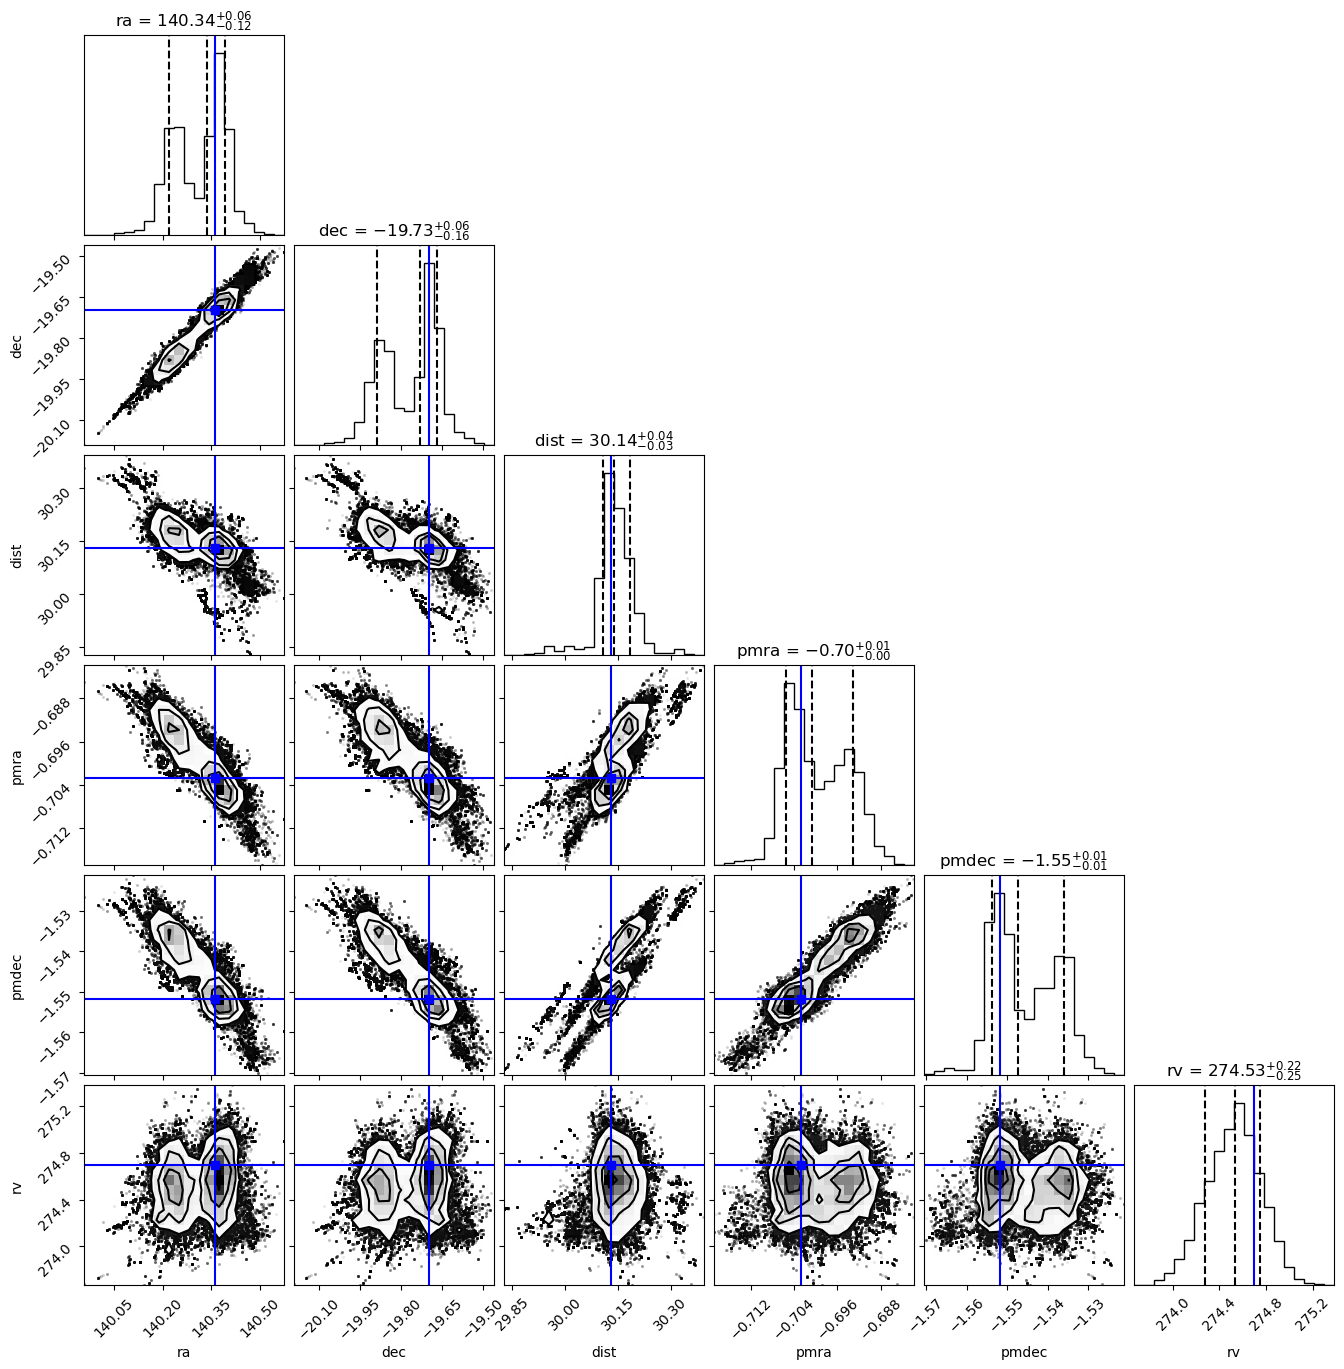

In [15]:
#MCMC checks!
labels = ['ra', 'dec', 'dist', 'pmra', 'pmdec', 'rv']

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truths=prog_pars_max,  # Show best fit
    truth_color='blue', fig_kwargs={'figsize': (6, 6)}
)
plt.show()

In [16]:
#plotting with corner plot histogram values

prog_pars_hist = [140.26,-19.83, 30.08, -0.70, -1.55, 274.18]

ra_hist, dec_hist, dist_hist, pmra_hist, pmdec_hist, rv_hist = prog_pars_hist

jet_c_hist = coord.SkyCoord(
    ra=ra_hist*u.degree, dec=dec_hist*u.degree, distance=dist_hist*u.kpc, 
    pm_ra_cosdec=pmra_hist*u.mas/u.yr,
    pm_dec=pmdec_hist*u.mas/u.yr,
    radial_velocity=rv_hist*u.km/u.s
)

rep_hist = jet_c_hist.transform_to(coord.Galactocentric) # units here are kpc, km/s

prog_hist_gal = np.array(
    [rep_hist.x.value, rep_hist.y.value, rep_hist.z.value,
     rep_hist.v_x.value, rep_hist.v_y.value, rep_hist.v_z.value]
) # units here are kpc, km/s

#generate the stream with best_fit_params
gen_hist_stream = jsf.create_stream_particle_spray(
    pot_host=potTotal, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_hist_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

#Cleaning up our coordinate frames *whistles nonchalantly*
hist_stream_model = gen_hist_stream['part_xv']

galcen_hist_stream = coord.Galactocentric(
        x=hist_stream_model[:,0] * u.kpc,
        y=hist_stream_model[:,1] * u.kpc,
        z=hist_stream_model[:,2] * u.kpc,
        v_x=hist_stream_model[:,3] * u.km/u.s,
        v_y=hist_stream_model[:,4] * u.km/u.s,
        v_z=hist_stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_hist_stream = galcen_hist_stream.transform_to(coord.ICRS())

ra_h = icrs_hist_stream.ra.value
dec_h = icrs_hist_stream.dec.value
dist_h = icrs_hist_stream.distance.value
pmra_h = icrs_hist_stream.pm_ra_cosdec.value
pmdec_h = icrs_hist_stream.pm_dec.value
rv_h = icrs_hist_stream.radial_velocity.value

phi1_h, phi2_h = icrs_to_jet(ra_h, dec_h)

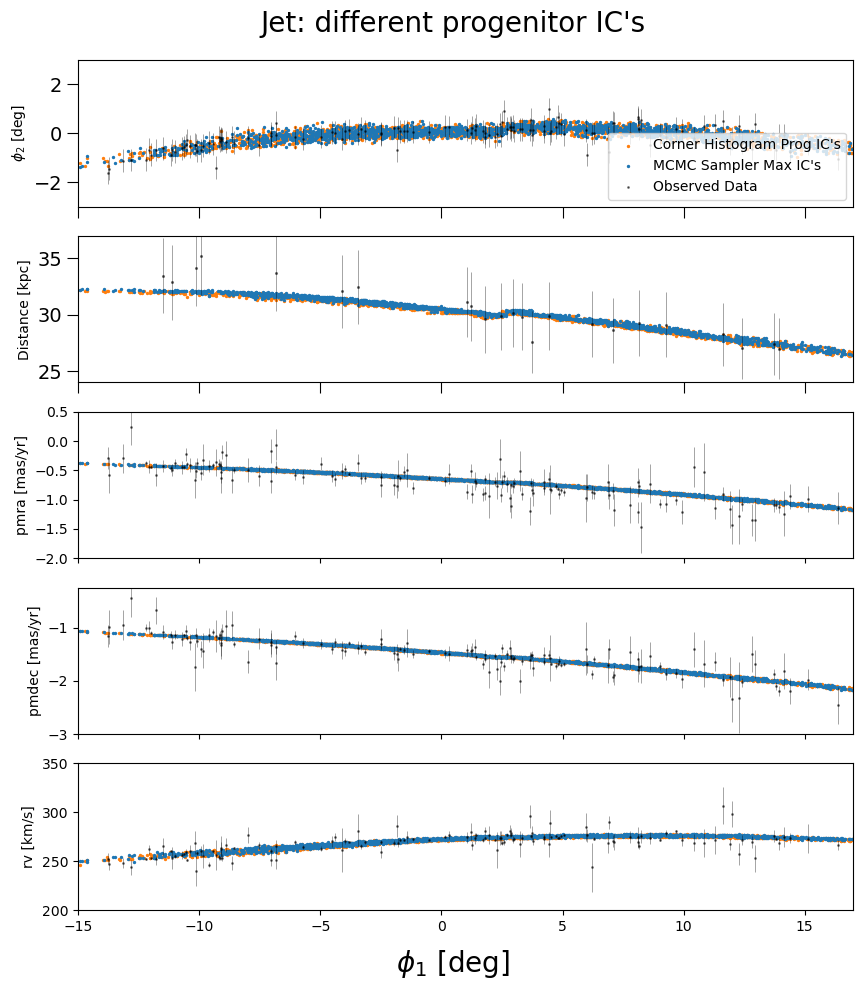

In [17]:
fig, ax = plt.subplots(5,1, sharex = True)
fig.suptitle(t ="Jet: different progenitor IC's",ha= 'center', fontsize = 20 )
fig.set_size_inches(10,10)
plt.subplots_adjust(top=0.93, bottom = 0.08)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-15,17)
#simulation
ax[0].scatter(phi1_h, phi2_h,s=2,color='tab:orange', label = "Corner Histogram Prog IC's")
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-3,3)

ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
ax[1].scatter(phi1_h, dist_h,s=2,color='tab:orange' )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
ax[1].set_ylim(24,37)

ax[2].scatter(phi1_h, pmra_h,s=2,color='tab:orange' )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
ax[2].set_ylim(-2,0.5)

ax[3].scatter(phi1_h, pmdec_h,s=2,color='tab:orange' )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
ax[3].set_ylim(-3,-0.25)

ax[4].scatter(phi1_h, rv_h,s=2,color='tab:orange',label = "Corner Histogram Prog IC's")
ax[4].set_ylabel('rv [km/s]', fontsize=10)
ax[4].set_ylim(200,350)


#theta_max IC's
ax[0].scatter(phi1_max, phi2_max,s=2,color='tab:blue', label = "MCMC Sampler Max IC's")
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)

ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
ax[1].scatter(phi1_max, dist_max,s=2,color='tab:blue' )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)

ax[2].scatter(phi1_max, pmra_max,s=2,color='tab:blue' )
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)

ax[3].scatter(phi1_max, pmdec_max,s=2,color='tab:blue' )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)

ax[4].scatter(phi1_max, rv_max,s=2,color='tab:blue', label = "MCMC Sampler Max IC's")
ax[4].set_ylabel('rv [km/s]', fontsize=10)


#data
ax[0].scatter(df['phi1'], df['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
ax[0].errorbar(df['phi1'], df['phi2'], yerr=np.nanstd(df['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df['phi1'], df['bhb_dist'],s=1.5,color='k', alpha = 0.5)
ax[1].errorbar(df['phi1'],df['bhb_dist'], yerr=((df['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df['phi1'], df['pmra'],s=1,color='k', alpha = 0.5)
ax[2].errorbar(df['phi1'], df['pmra'], yerr=df['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df['phi1'], df['pmdec'],s=1,color='k',alpha = 0.5)
ax[3].errorbar(df['phi1'], df['pmdec'], yerr=df['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df['phi1'], df['vel_calib'],s=1,color='k', alpha = 0.5)
ax[4].errorbar(df['phi1'], df['vel_calib'], yerr=df['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[0].legend(loc = 'lower right')